Original data shape: (70, 36)

Job Recommendation Statistics:
Job_Recommendation
Software Developer                          24
Information Security Analyst                10
Full Stack Developer with Security Focus     9
Data Analyst                                 7
Junior Software Developer                    5
Junior Data Analyst                          4
Consider additional training                 3
Junior Security Analyst                      2
Cybersecurity Engineer                       2
Data Scientist                               2
Name: count, dtype: int64
Job recommendations saved to job_recommendations.csv
Analysis complete!

Analysis of recommendations by predominant skill area:

Top performers in Software Development (41 students):
  - Software Developer: 24 students
  - Full Stack Developer with Security Focus: 9 students
  - Information Security Analyst: 2 students

Top performers in Data Science (25 students):
  - Full Stack Developer with Security Focus: 9 student

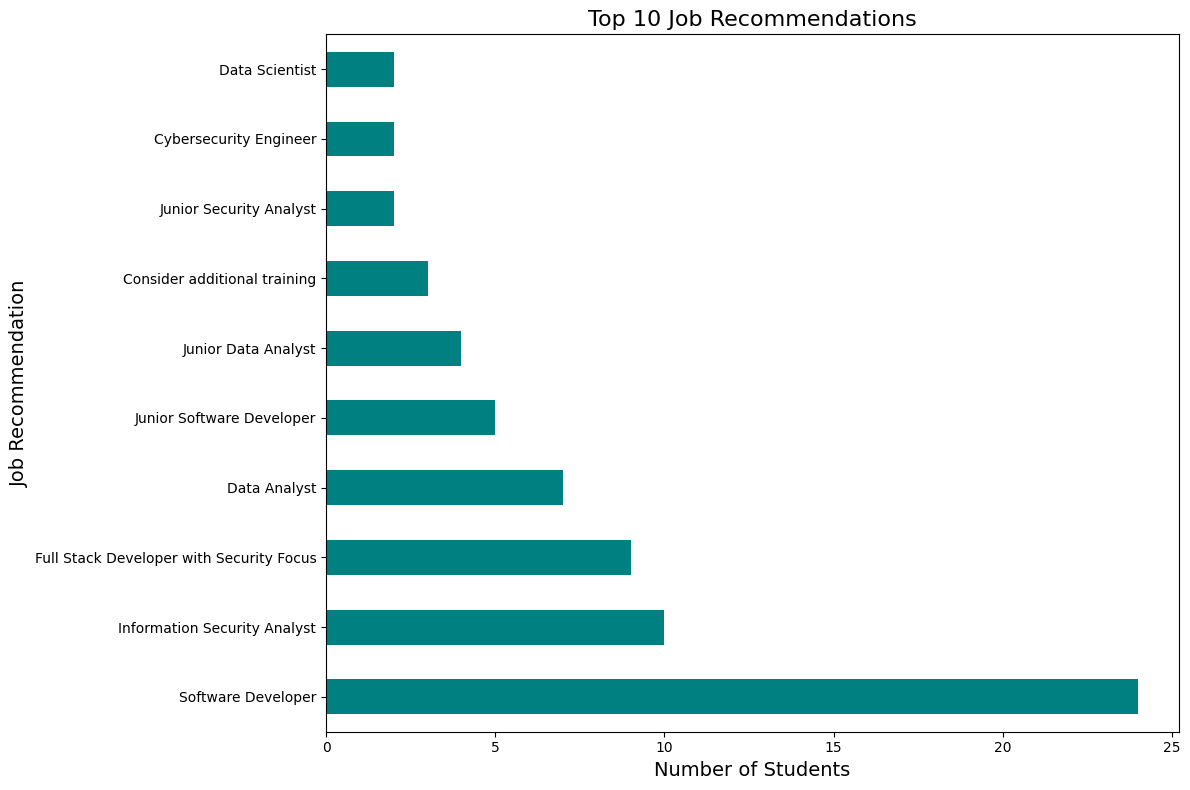

<Figure size 1400x1000 with 0 Axes>

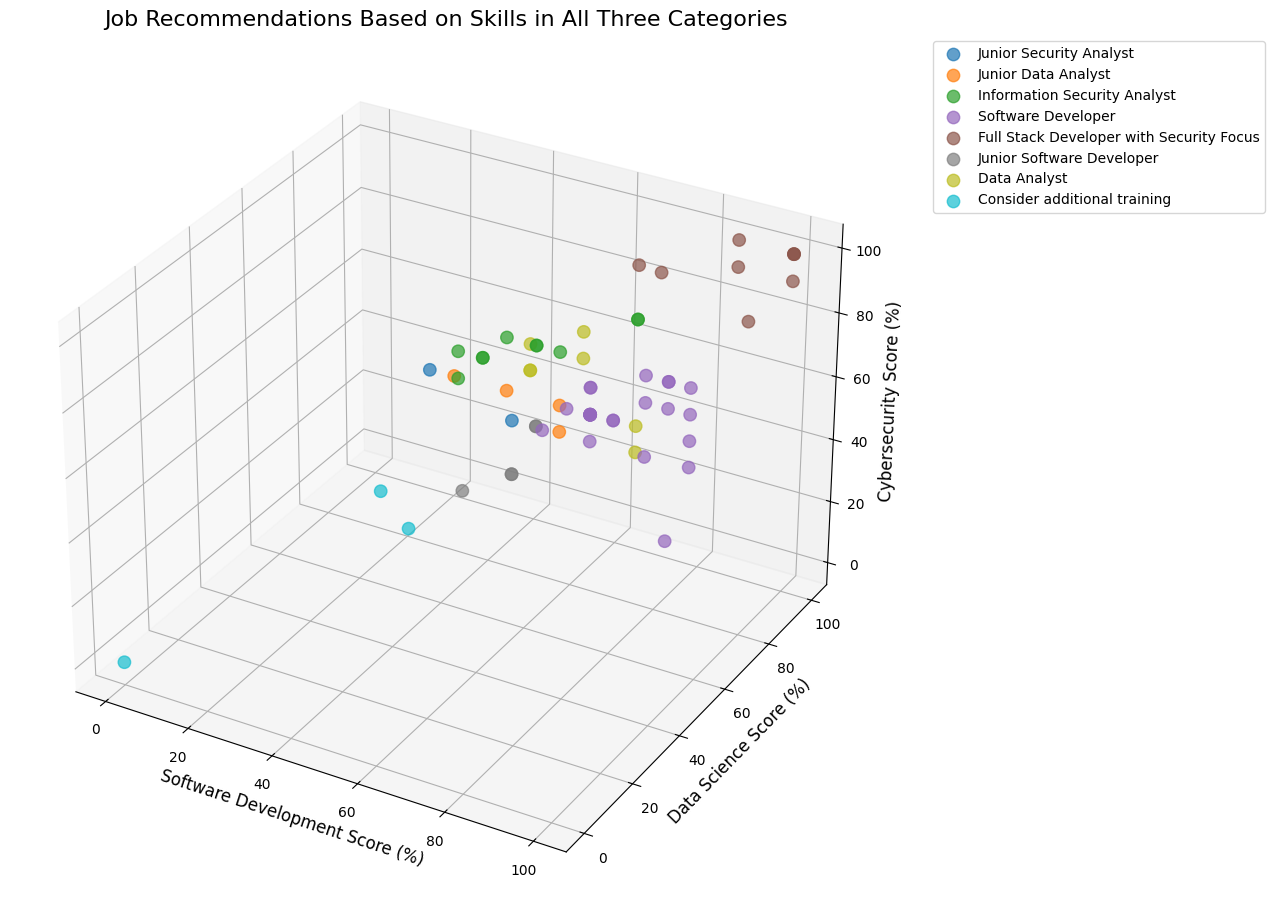

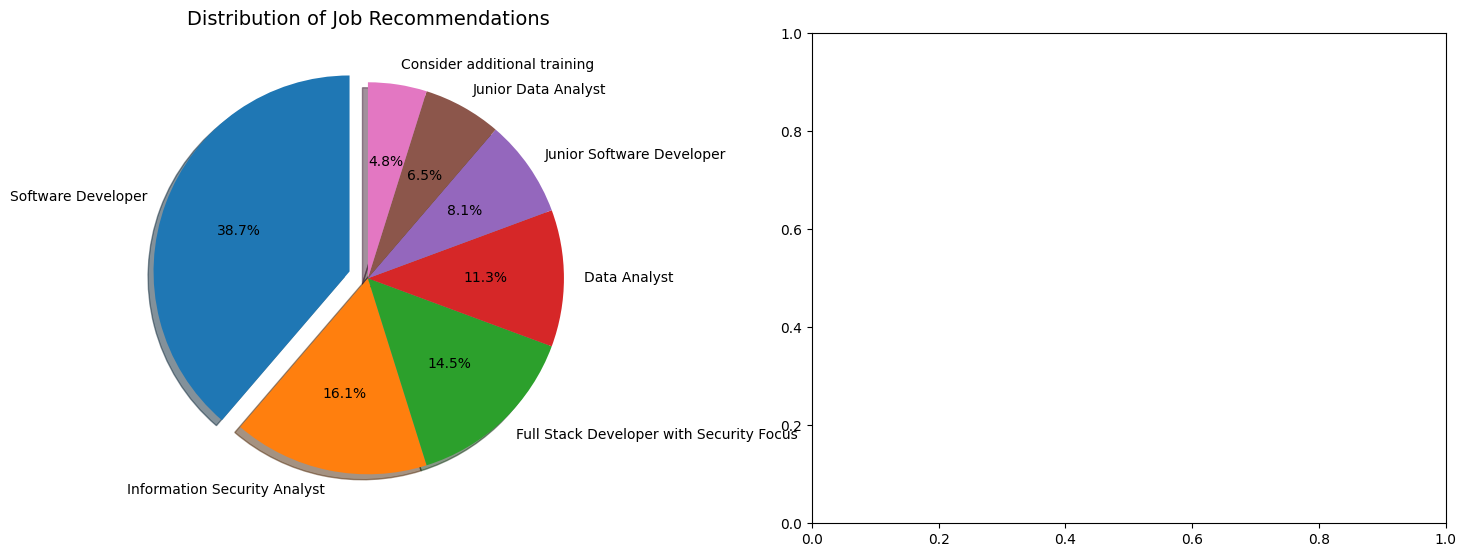

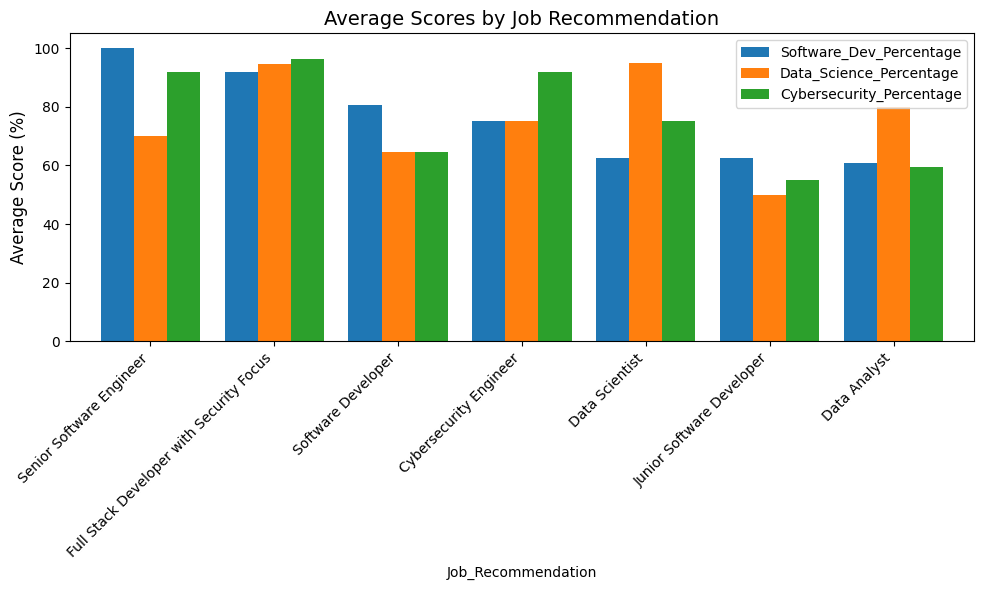

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
input_file = "output.csv"
output_file = "job_recommendations.csv"
df = pd.read_csv(input_file)

print(f"Original data shape: {df.shape}")

In [ ]:
def convert_to_binary(value):
    if pd.isna(value) or value in ['', 'N/A', 'NA', '0', 0, '-1', 'FALSE', 'False', 'false']:
        return 0
    elif value in ['1', 1, 'YES', 'Yes', 'yes', 'TRUE', 'True', 'true', 'x', 'y']:
        return 1
    try:
        num_value = float(value)
        return 1 if num_value > 0 else 0
    except:
        return 1

In [ ]:
df['Name'] = df['Name'].apply(lambda x: x.replace(' ', '_') if isinstance(x, str) and ' ' in x else x)
df['Email'] = df['Email'].apply(lambda x: x.replace('-', '@') if isinstance(x, str) and '-' in x else x)
df['Name'] = df['Name'].fillna('Unknown_Student')
df['Category_2'] = df['Category_2'].apply(lambda x: 'Data Science' if isinstance(x, str) and x == 'Data Sciencce' else x)
df['Category_3'] = df['Category_3'].apply(lambda x: 'Cybersecurity' if x == 'TRUE' else x)

category_columns = ['Category_1', 'Category_2', 'Category_3']
for col in category_columns:
    df[col] = df[col].fillna('None')

In [ ]:
answer_columns = df.columns[6:]

df.loc[62, answer_columns] = 1
df.loc[63, answer_columns] = 1

for col in answer_columns:
    df[col] = df[col].astype(str)
    df[col] = df[col].apply(lambda x: convert_to_binary(x))

for col in answer_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

software_dev_questions = answer_columns[:8]
data_science_questions = answer_columns[8:18]
cybersecurity_questions = answer_columns[18:]

In [ ]:
df['Software_Dev_Score'] = df[software_dev_questions].sum(axis=1)
df['Software_Dev_Percentage'] = (df['Software_Dev_Score'] / len(software_dev_questions)) * 100

df['Data_Science_Score'] = df[data_science_questions].sum(axis=1)
df['Data_Science_Percentage'] = (df['Data_Science_Score'] / len(data_science_questions)) * 100

df['Cybersecurity_Score'] = df[cybersecurity_questions].sum(axis=1)
df['Cybersecurity_Percentage'] = (df['Cybersecurity_Score'] / len(cybersecurity_questions)) * 100

df['Total_Score'] = df[answer_columns].sum(axis=1)
df['Score_Percentage'] = (df['Total_Score'] / len(answer_columns)) * 100

In [ ]:
def recommend_job(row):
    sw_score = row['Software_Dev_Percentage']
    ds_score = row['Data_Science_Percentage']
    cs_score = row['Cybersecurity_Percentage']
    overall_score = row['Score_Percentage']

    high_threshold = 75
    medium_threshold = 60

    domain_scores = {
        "Software Development": sw_score,
        "Data Science": ds_score,
        "Cybersecurity": cs_score
    }

    primary_domain = max(domain_scores, key=domain_scores.get)
    primary_score = domain_scores[primary_domain]

    secondary_domain = sorted(domain_scores.items(), key=lambda x: x[1], reverse=True)[1][0]
    secondary_score = domain_scores[secondary_domain]

    score_gap = primary_score - secondary_score

    job_titles = {
        "Software Development": {
            "expert": "Senior Software Engineer",
            "proficient": "Software Developer",
            "entry": "Junior Software Developer"
        },
        "Data Science": {
            "expert": "Data Scientist",
            "proficient": "Data Analyst",
            "entry": "Junior Data Analyst"
        },
        "Cybersecurity": {
            "expert": "Cybersecurity Engineer",
            "proficient": "Information Security Analyst",
            "entry": "Junior Security Analyst"
        }
    }

    hybrid_roles = {
        ("Software Development", "Data Science"): "Machine Learning Engineer",
        ("Software Development", "Cybersecurity"): "Security Developer",
        ("Data Science", "Cybersecurity"): "Security Data Analyst",
        ("all_high"): "Full Stack Developer with Security Focus"
    }

    if primary_score >= 90:
        expertise = "expert"
    elif primary_score >= high_threshold:
        expertise = "proficient"
    elif primary_score >= medium_threshold:
        expertise = "entry"
    else:
        return "IT Support Specialist" if overall_score >= 50 else "Consider additional training"

    if primary_score >= high_threshold and secondary_score >= high_threshold:
        if score_gap <= 15:
            domains = tuple(sorted([primary_domain, secondary_domain]))

            if domains in hybrid_roles:
                return hybrid_roles[domains]

        all_domains_high = all(score >= high_threshold for score in domain_scores.values())
        if all_domains_high and overall_score >= 85:
            return hybrid_roles["all_high"]

    return job_titles[primary_domain][expertise]

In [ ]:
df['Job_Recommendation'] = df.apply(recommend_job, axis=1)

print("\nJob Recommendation Statistics:")
recommendation_counts = df['Job_Recommendation'].value_counts()
print(recommendation_counts.head(10))

In [ ]:
plt.figure(figsize=(12, 8))
recommendation_counts = df['Job_Recommendation'].value_counts()
recommendation_counts.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Job Recommendations', fontsize=16)
plt.xlabel('Number of Students', fontsize=14)
plt.ylabel('Job Recommendation', fontsize=14)
plt.tight_layout()
plt.savefig('job_recommendations_chart.png', dpi=300, bbox_inches='tight')

df.to_csv(output_file, index=False)
print(f"Job recommendations saved to {output_file}")

In [ ]:
plt.figure(figsize=(14, 10))
top_recommendations = recommendation_counts.head(8).index.tolist()
filtered_df = df[df['Job_Recommendation'].isin(top_recommendations)]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, len(filtered_df['Job_Recommendation'].unique())))
color_map = dict(zip(filtered_df['Job_Recommendation'].unique(), colors))
for job in filtered_df['Job_Recommendation'].unique():
    job_df = filtered_df[filtered_df['Job_Recommendation'] == job]
    ax.scatter(
        job_df['Software_Dev_Percentage'],
        job_df['Data_Science_Percentage'],
        job_df['Cybersecurity_Percentage'],
        label=job,
        s=80,
        alpha=0.7,
        c=[color_map[job]]
    )

ax.set_xlabel('Software Development Score (%)', fontsize=12)
ax.set_ylabel('Data Science Score (%)', fontsize=12)
ax.set_zlabel('Cybersecurity Score (%)', fontsize=12)
ax.set_title('Job Recommendations Based on Skills in All Three Categories', fontsize=16)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('job_recommendations_3d.png', dpi=300, bbox_inches='tight')

In [ ]:
print("Analysis complete!")
print("\nAnalysis of recommendations by predominant skill area:")
skill_areas = ['Software Development', 'Data Science', 'Cybersecurity']

for area in skill_areas:
    area_column = f"{area.replace(' ', '_')}_Percentage"
    if area == 'Software Development':
        area_column = 'Software_Dev_Percentage'
    elif area == 'Data Science':
        area_column = 'Data_Science_Percentage'
    elif area == 'Cybersecurity':
        area_column = 'Cybersecurity_Percentage'

    high_performers = df[df[area_column] >= 75]
    print(f"\nTop performers in {area} ({len(high_performers)} students):")
    area_recommendations = high_performers['Job_Recommendation'].value_counts()
    for rec, count in area_recommendations.head(3).items():
        print(f"  - {rec}: {count} students")

In [ ]:
plt.figure(figsize=(18, 14))

plt.subplot(2, 2, 1)
top_recommendations = recommendation_counts.head(7)
explode = [0.1] + [0] * (len(top_recommendations) - 1)
plt.pie(top_recommendations, labels=top_recommendations.index, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True)
plt.title('Distribution of Job Recommendations', fontsize=14)
plt.subplot(2, 2, 2)
avg_scores = df.groupby('Job_Recommendation')[['Software_Dev_Percentage', 'Data_Science_Percentage', 'Cybersecurity_Percentage']].mean()
avg_scores = avg_scores.sort_values('Software_Dev_Percentage', ascending=False).head(7)
avg_scores.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Average Scores by Job Recommendation', fontsize=14)
plt.ylabel('Average Score (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()

In [ ]:
try:
    model = joblib.load('job_recommendation_model.pkl')
    print("\nValidating recommendations against machine learning model...")

    X = df.drop(columns=['Student_ID', 'Name', 'Email', 'Category_1', 'Category_2', 'Category_3', 'Job_Recommendation'])
    label_encoder = LabelEncoder()

    df['ML_Category'] = df['Category_1']
    validation_report = pd.DataFrame({
        'Student': df['Name'],
        'Rule_Based_Recommendation': df['Job_Recommendation'],
        'ML_Category': df['ML_Category']
    })

    print("Validation sample (first 5 records):")
    print(validation_report.head(5))
    validation_report.to_csv('recommendation_validation.csv', index=False)

except FileNotFoundError:
    print("\nOriginal model file not found. Skipping validation against machine learning model.")